In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set visual style
sns.set_style("darkgrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Load Raw Data
# We use '..' to go up one level from 'notebooks/' to the root
df_sp = pd.read_csv("../data/raw/sp500_daily.csv", index_col=0, parse_dates=True)
df_vix = pd.read_csv("../data/raw/vix_daily.csv", index_col=0, parse_dates=True)

print(f"S&P 500 Range: {df_sp.index.min().date()} to {df_sp.index.max().date()}")
print(f"VIX Range:     {df_vix.index.min().date()} to {df_vix.index.max().date()}")

S&P 500 Range: 2000-01-03 to 2026-01-30
VIX Range:     2000-01-03 to 2026-01-30


In [2]:
# Create a temporary dataframe for plotting
df = pd.DataFrame()
df['Price'] = df_sp['Close']
df['VIX'] = df_vix['Close']

# 1. Log Returns (Daily % move)
df['Log_Ret'] = np.log(df['Price'] / df['Price'].shift(1))

# 2. Realized Volatility (The Truth)
# Calculate standard deviation of the last 21 days (1 month)
# Multiply by sqrt(252) to annualize it
df['Vol_21d'] = df['Log_Ret'].rolling(window=21).std() * np.sqrt(252)

df = df.dropna()
df[['Price', 'Log_Ret', 'Vol_21d', 'VIX']].tail()

,Price,Log_Ret,Vol_21d,VIX
Date,,,,
2026-01-26,6950.229980,0.004994,0.105116,16.150000
2026-01-27,6978.600098,0.004074,0.105459,16.350000
2026-01-28,6978.029785,-0.000082,0.105445,16.350000
2026-01-29,6969.009766,-0.001293,0.104711,16.879999
2026-01-30,6928.709961,-0.005800,0.106775,17.010000


Now we will be looking for volatility clustering. If sudden outbursts of log return sis observed for months and if it is followed by quiet period that signifies volatility clustering as volatility is sticky in nature that is mathematically it follows how it was a day before and changes gradually.

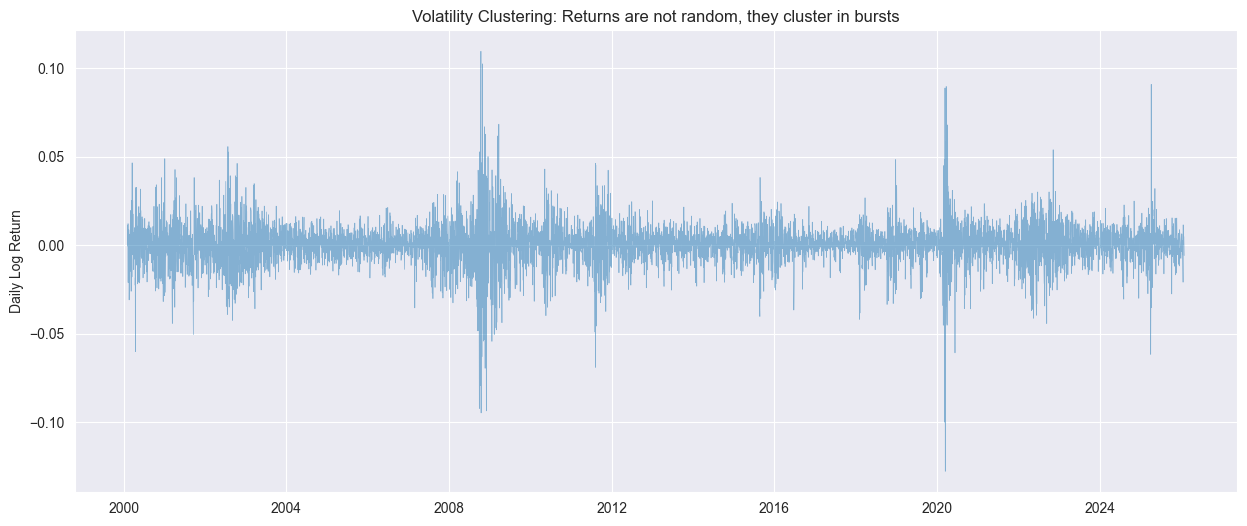

In [3]:
plt.figure(figsize=(15, 6))
plt.plot(df.index, df['Log_Ret'], alpha=0.5, linewidth=0.5)
plt.title('Volatility Clustering: Returns are not random, they cluster in bursts')
plt.ylabel('Daily Log Return')
plt.show()

Sudden bursts can be observed for the years 2008 and 2020. Represents the market crashes observed during those periods and also the nature of volatility.

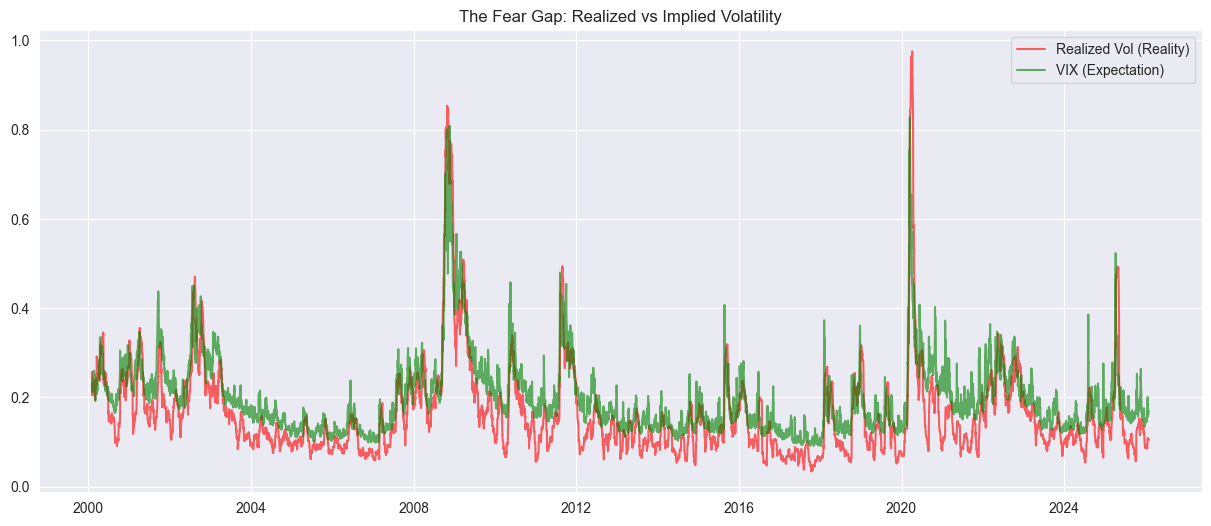

In [4]:
plt.figure(figsize=(15, 6))
plt.plot(df.index, df['Vol_21d'], color='red', label='Realized Vol (Reality)', alpha=0.6)
plt.plot(df.index, df['VIX'] / 100, color='green', label='VIX (Expectation)', alpha=0.6)
plt.title('The Fear Gap: Realized vs Implied Volatility')
plt.legend()
plt.show()

Here we can see a comparision drawn between VIX and actual volatility and also how the VIX line stays above the actual volatility showing a healthy market. In the years of 2008 and 2020 we can see the red line leading above which confirms the vix features as it shows us a crash.

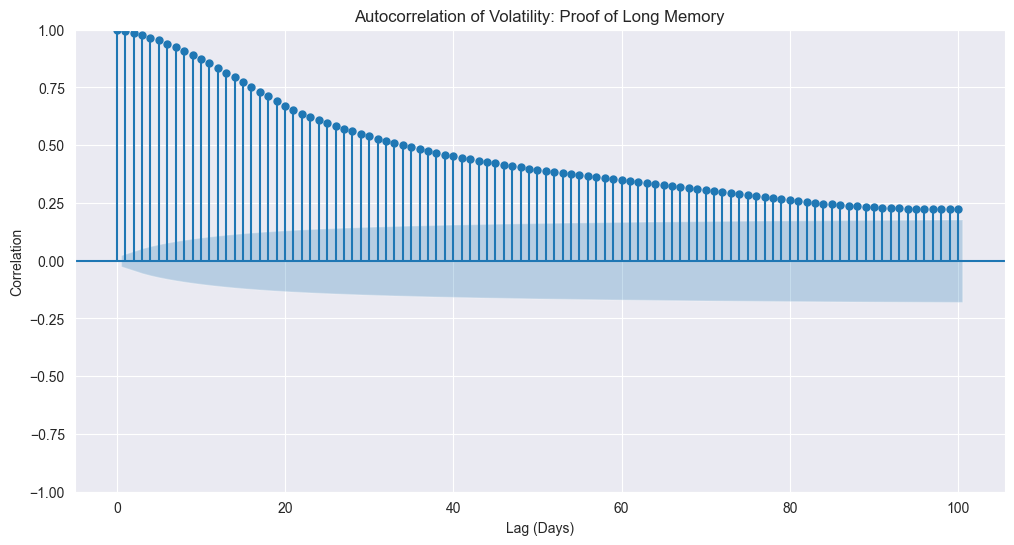

In [5]:
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(figsize=(12, 6))
plot_acf(df['Vol_21d'].dropna(), lags=100, ax=ax)
plt.title('Autocorrelation of Volatility: Proof of Long Memory')
plt.xlabel('Lag (Days)')
plt.ylabel('Correlation')
plt.show()

Because they stay high for 100+ days, it proves that volatility is "sticky." High risk today strongly predicts high risk next week. This confirms that a Machine Learning model can actually learn this pattern.

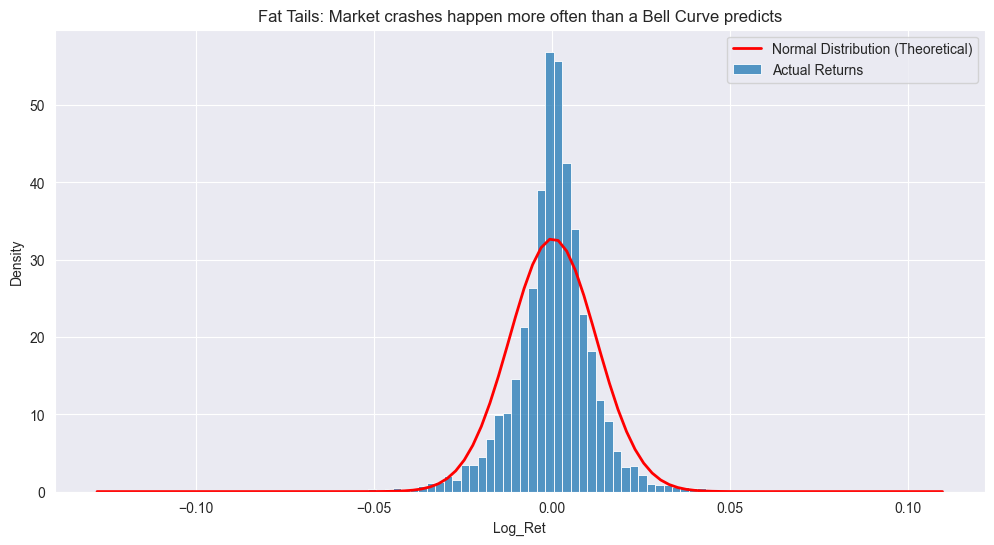

In [6]:
from scipy.stats import norm

plt.figure(figsize=(12, 6))
sns.histplot(df['Log_Ret'], bins=100, stat='density', label='Actual Returns', kde=False)

mu, std = norm.fit(df['Log_Ret'])
x = np.linspace(df['Log_Ret'].min(), df['Log_Ret'].max(), 100)
p = norm.pdf(x, mu, std)

plt.plot(x, p, 'r', linewidth=2, label='Normal Distribution (Theoretical)')
plt.title('Fat Tails: Market crashes happen more often than a Bell Curve predicts')
plt.legend()
plt.show()

The blue bars piercing through the red curve prove Kurtosis. The market is "wilder" than standard statistics assumes.